In [1]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

# Analytic Investigation

## Data loading

In [2]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("./Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("./Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("./Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

# amounts: see './Biotypes/updated-biotypes.ipynb' for full pie chart of types
print(f"Total of {data_FIB.shape[0]} genes with mean > 1 present \nSelected {data_FIB_miRNA.shape[0]} non-coding miRNA \nSelected {data_FIB_pcRNA.shape[0]} protein coding (mRNA)")

Total of 11747 genes with mean > 1 present 
Selected 19 non-coding miRNA 
Selected 9296 protein coding (mRNA)


## Setup functions

In [4]:
def analytic_correlation_bootstrap_sample(x1_sample, x2_sample, beta, confidence=None, resamples=None):

    # get sample size
    n = len(x1_sample)

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n
    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95

    # initialize random generator
    rng = np.random.default_rng()

    # separate sample pairs
    x1_sample = list(x1_sample)
    x2_sample = list(x2_sample)

    # convert sample to n x 2 array
    sample = np.array([x1_sample, x2_sample]).T

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        b1 = boot[i, :, 0]
        b2 = boot[i, :, 1]

        # OB moments
        E_xy_OB = np.mean(b1 * b2)
        E_x_OB = np.mean(b1)
        E_y_OB = np.mean(b2)
        E_x2_OB = np.mean(b1**2)
        E_y2_OB = np.mean(b2**2)

        # OG moments
        E_xy_OG = E_xy_OB / E_beta2
        E_x_OG = E_x_OB / E_beta
        E_y_OG = E_y_OB / E_beta
        E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
        E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

        varx_OG = E_x2_OG - E_x_OG**2
        vary_OG = E_y2_OG - E_y_OG**2

        if varx_OG <= 0.0 or vary_OG <= 0.0:
            corr = np.nan
        else:
            corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

        estimates[i] = corr

    # take quantiles
    alpha = 1 - confidence
    interval = np.quantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # compute point estimate from original sample
    b1 = np.array(x1_sample)
    b2 = np.array(x2_sample)

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    # collect results
    result = np.array([
        corr,
        interval[0],
        interval[1]
    ])

    return result

In [5]:
def analytic_correlation_bootstrap_dataset(mirna_sample, mrna_dataset, beta, confidence=None, resamples=None):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # record results
    results = np.empty((gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(gene_pairs)):
        results[i, :] = analytic_correlation_bootstrap_sample(mirna_sample, mrna_dataset.iloc[i], beta, confidence, resamples)

    return results

## Setup results

### Construct

In [29]:
# select mRNA
mRNA = data_FIB_pcRNA.index

In [30]:
# dataframe to store results
analytic_df = pd.DataFrame(
    index=mRNA
)

## Running

In [ ]:
# for each miRNA
miRNA_names = data_FIB_miRNA.index
for miRNA in miRNA_names:

    # display miRNA
    print(f"\nRunning {miRNA}")

    # compute analytic correlation point and interval estimates
    analytic_results = analytic_correlation_bootstrap_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA, beta)

    # extract results (rho same for 1 or 2 sided test)
    rho = analytic_results[:, 0]
    lb = analytic_results[:, 1]
    ub = analytic_results[:, 2]

    # store on dataframe
    analytic_df[f'{miRNA}_rho'] = rho
    analytic_df[f'{miRNA}_lb'] = lb
    analytic_df[f'{miRNA}_ub'] = ub

    # save dataframes as safety
    #analytic_df.to_csv("Results/analytic.csv")  # Uncomment when running
    #analytic_df.to_csv("Results/analytic.csv")


Running MIR100


100%|██████████| 9296/9296 [01:47<00:00, 86.84it/s]



Running MIR103A2


100%|██████████| 9296/9296 [01:47<00:00, 86.64it/s]



Running MIR16-2


...

100%|██████████| 9296/9296 [03:35<00:00, 43.23it/s]



Running MIRLET7A2


100%|██████████| 9296/9296 [03:28<00:00, 44.53it/s]



Running MIRLET7D


100%|██████████| 9296/9296 [03:28<00:00, 44.49it/s]


## Numerical errors

When variance(s) are large, the additional scaling by capture moments leads to very large values which can give instability in correlation values and produce results outside the interval $[-1, 1]$:

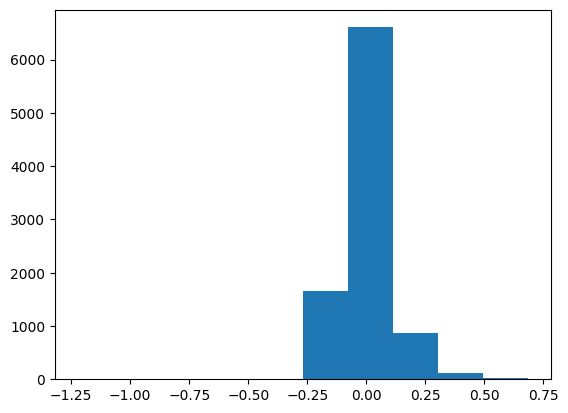

In [9]:
plt.hist(analytic_results[:, 0]);

In [10]:
mask = (analytic_results[:, 0] < -1)

In [11]:
data_FIB_pcRNA.index[mask]

Index(['LDHA'], dtype='object')

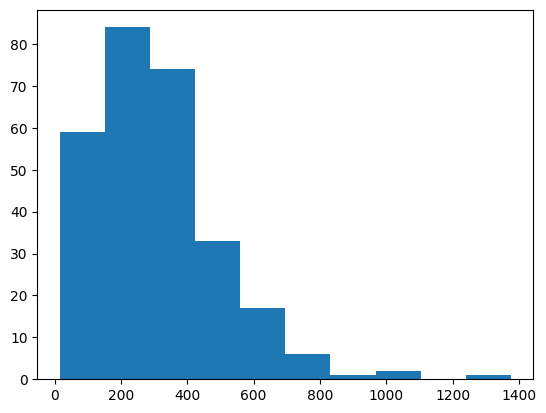

In [12]:
plt.hist(data_FIB_pcRNA.loc['LDHA']);

In [13]:
analytic_correlation_bootstrap_sample(data_FIB_miRNA.loc['MIR100'], data_FIB_pcRNA.loc['LDHA'], beta)

array([-1.22353244,         nan,         nan])

In [15]:
b1 = np.array(data_FIB_miRNA.loc['MIR100'])
b2 = np.array(data_FIB_pcRNA.loc['LDHA'])

E_beta = np.mean(beta)
E_beta2 = np.mean(beta**2)

# OB moments
E_xy_OB = np.mean(b1 * b2)
E_x_OB = np.mean(b1)
E_y_OB = np.mean(b2)
E_x2_OB = np.mean(b1**2)
E_y2_OB = np.mean(b2**2)

# OG moments
E_xy_OG = E_xy_OB / E_beta2
E_x_OG = E_x_OB / E_beta
E_y_OG = E_y_OB / E_beta
E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

varx_OG = E_x2_OG - E_x_OG**2
vary_OG = E_y2_OG - E_y_OG**2

if varx_OG <= 0.0 or vary_OG <= 0.0:
    corr = np.nan
else:
    corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

corr

np.float64(-1.223532441913528)

In [28]:
E_y2_OG

np.float64(9501959.219763154)

In [25]:
varx_OB = E_x2_OB - E_x_OB**2
vary_OB = E_y2_OB - E_y_OB**2

if varx_OB <= 0.0 or vary_OB <= 0.0:
    corr = np.nan
else:
    corr = (E_xy_OB - E_x_OB*E_y_OB) / (np.sqrt(varx_OB) * np.sqrt(vary_OB))

corr

np.float64(0.0846206042952309)